### CLASSIFICATION

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve, roc_auc_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [5]:
import pandas as pd
file_path=r'C:\Users\Dell\OneDrive\Desktop\student_digital_life.csv'
df=pd.read_csv(file_path)
print(df.head())

   student_id  age  gender  study_hours_per_day  smartphone_usage_hours  \
0           1   21  Female                 3.01                    0.26   
1           2   23  Female                 5.84                    8.02   
2           3   20  Female                 7.80                   10.13   
3           4   20  Female                 0.00                    1.15   
4           5   24    Male                 7.23                    1.39   

   social_media_hours  gaming_hours  streaming_hours  sleep_hours  \
0                1.77          0.26             1.71         5.32   
1                3.30          0.96             0.00         5.99   
2                0.00          2.23             2.54         6.36   
3                1.32          4.19             0.27         7.86   
4                2.21          4.67             2.75         7.88   

   exercise_hours  class_attendance_percent  assignment_completion_percent  \
0            0.70                     64.87             

In [3]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
14995    False
14996    False
14997    False
14998    False
14999    False
Length: 15000, dtype: bool

In [4]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     15000 non-null  int64  
 1   age                            15000 non-null  int64  
 2   gender                         15000 non-null  object 
 3   study_hours_per_day            15000 non-null  float64
 4   smartphone_usage_hours         15000 non-null  float64
 5   social_media_hours             15000 non-null  float64
 6   gaming_hours                   15000 non-null  float64
 7   streaming_hours                15000 non-null  float64
 8   sleep_hours                    15000 non-null  float64
 9   exercise_hours                 15000 non-null  float64
 10  class_attendance_percent       15000 non-null  float64
 11  assignment_completion_percent  15000 non-null  float64
 12  caffeine_intake_cups           15000 non-null 

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
smartphone_usage_hours           0
social_media_hours               0
gaming_hours                     0
streaming_hours                  0
sleep_hours                      0
exercise_hours                   0
class_attendance_percent         0
assignment_completion_percent    0
caffeine_intake_cups             0
mental_health_status             0
parent_education_level           0
internet_quality                 0
motivation_level                 0
final_exam_score                 0
dtype: int64

In [5]:
df['gender'] = df['gender'].map({'Male':1, 'Female':0})

print(df.head())

   student_id  age  gender  study_hours_per_day  smartphone_usage_hours  \
0           1   21       0                 3.01                    0.26   
1           2   23       0                 5.84                    8.02   
2           3   20       0                 7.80                   10.13   
3           4   20       0                 0.00                    1.15   
4           5   24       1                 7.23                    1.39   

   social_media_hours  gaming_hours  streaming_hours  sleep_hours  \
0                1.77          0.26             1.71         5.32   
1                3.30          0.96             0.00         5.99   
2                0.00          2.23             2.54         6.36   
3                1.32          4.19             0.27         7.86   
4                2.21          4.67             2.75         7.88   

   exercise_hours  class_attendance_percent  assignment_completion_percent  \
0            0.70                     64.87             

In [6]:
df = df.drop(columns=['student_id'], errors='ignore')

In [7]:
df = df.dropna()

In [8]:
print(df.head())

   age  gender  study_hours_per_day  smartphone_usage_hours  \
0   21       0                 3.01                    0.26   
1   23       0                 5.84                    8.02   
2   20       0                 7.80                   10.13   
3   20       0                 0.00                    1.15   
4   24       1                 7.23                    1.39   

   social_media_hours  gaming_hours  streaming_hours  sleep_hours  \
0                1.77          0.26             1.71         5.32   
1                3.30          0.96             0.00         5.99   
2                0.00          2.23             2.54         6.36   
3                1.32          4.19             0.27         7.86   
4                2.21          4.67             2.75         7.88   

   exercise_hours  class_attendance_percent  assignment_completion_percent  \
0            0.70                     64.87                          74.11   
1            1.99                     85.38       

In [9]:

df['performance'] = df['final_exam_score'].apply(lambda x: 1 if x >= 75 else 0)

In [10]:
le = LabelEncoder()

categorical_cols = ['gender', 'mental_health_status', 
                    'parent_education_level', 'internet_quality']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [11]:
X = df.drop(['final_exam_score', 'performance'], axis=1)
y = df['performance']

In [12]:
print(df.head())


   age  gender  study_hours_per_day  smartphone_usage_hours  \
0   21       0                 3.01                    0.26   
1   23       0                 5.84                    8.02   
2   20       0                 7.80                   10.13   
3   20       0                 0.00                    1.15   
4   24       1                 7.23                    1.39   

   social_media_hours  gaming_hours  streaming_hours  sleep_hours  \
0                1.77          0.26             1.71         5.32   
1                3.30          0.96             0.00         5.99   
2                0.00          2.23             2.54         6.36   
3                1.32          4.19             0.27         7.86   
4                2.21          4.67             2.75         7.88   

   exercise_hours  class_attendance_percent  assignment_completion_percent  \
0            0.70                     64.87                          74.11   
1            1.99                     85.38       

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [16]:
y_pred = model.predict(X_test)

In [17]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Accuracy: 0.819
Precision: 0.8449760765550239
Recall: 0.8896725440806046


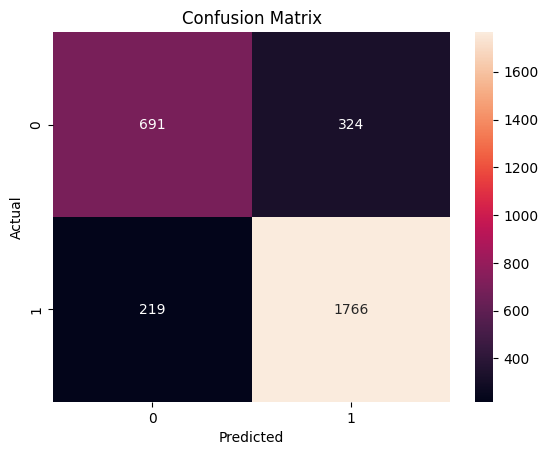

In [18]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

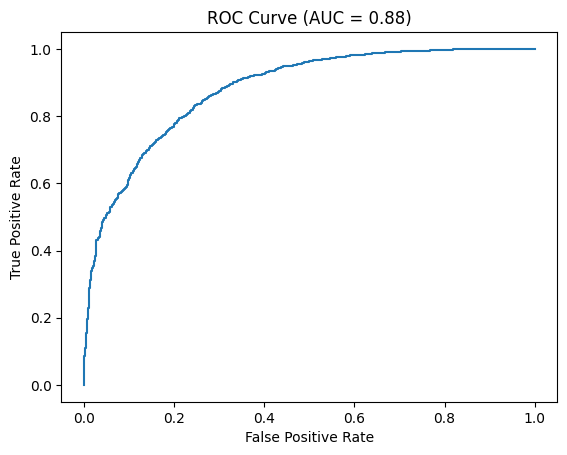

In [20]:
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (AUC = %0.2f)" % roc_auc)
plt.show()

In [1]:
import pandas as pd
file_path=r'C:\Users\Dell\OneDrive\Desktop\student_digital_life.csv'
df=pd.read_csv(file_path)
print(df.head())

   student_id  age  gender  study_hours_per_day  smartphone_usage_hours  \
0           1   21  Female                 3.01                    0.26   
1           2   23  Female                 5.84                    8.02   
2           3   20  Female                 7.80                   10.13   
3           4   20  Female                 0.00                    1.15   
4           5   24    Male                 7.23                    1.39   

   social_media_hours  gaming_hours  streaming_hours  sleep_hours  \
0                1.77          0.26             1.71         5.32   
1                3.30          0.96             0.00         5.99   
2                0.00          2.23             2.54         6.36   
3                1.32          4.19             0.27         7.86   
4                2.21          4.67             2.75         7.88   

   exercise_hours  class_attendance_percent  assignment_completion_percent  \
0            0.70                     64.87             

### CLUSTERING

In [2]:
X_cluster = df[['study_hours_per_day',
                'social_media_hours',
                'sleep_hours',
                'exercise_hours',
                'final_exam_score']]

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

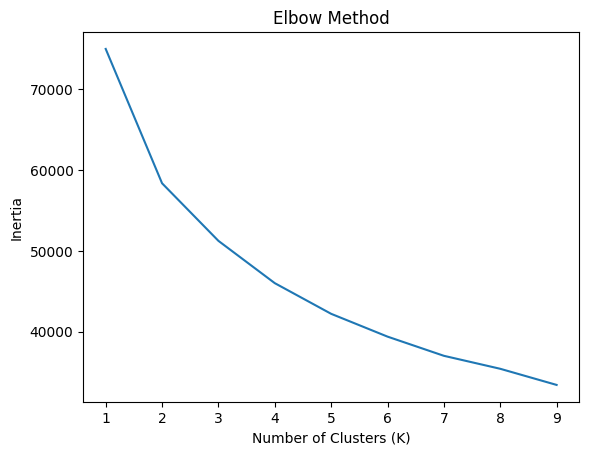

In [7]:

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters

In [9]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.16865508766336113


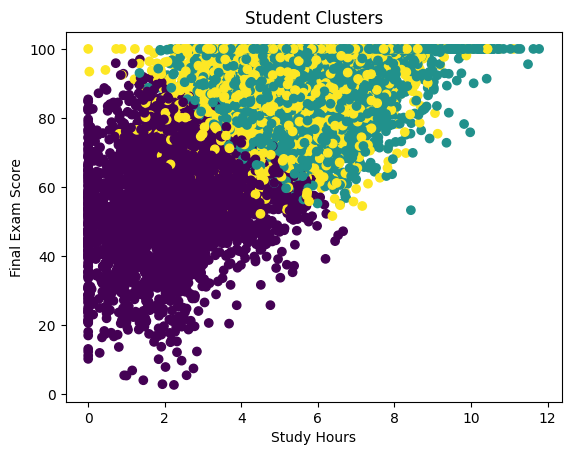

In [10]:
plt.scatter(df['study_hours_per_day'],
            df['final_exam_score'],
            c=df['cluster'])

plt.xlabel("Study Hours")
plt.ylabel("Final Exam Score")
plt.title("Student Clusters")
plt.show()